# 01 — Dataset EDA: Samanantar English → Odia Parallel Corpus

**Project:** OdiaTransformer (Test-7)
**Phase:** 1 — EDA and preprocessing-rule discovery
**Dataset:** `dataset/train-00000-of-00001.parquet` (Samanantar, Odia `or` config)
**SourceDoc:** `dataset/README.md` (creator's dataset card) and `dataset/dataset_info.md`

**Goal:** Characterize the raw English→Odia parallel corpus *without modifying it*, so that preprocessing rules can be derived from evidence rather than assumed.

**Mode:** READ-ONLY. We do not filter, drop, overwrite, or transform the raw dataset. Every cleaning candidate is recorded as a *Finding / Evidence / Potential preprocessing decision* in the final summary for later implementation.

## 1. Title and Objective

We inspect the Samanantar Odia parallel corpus to answer, with evidence:
- How many sentence pairs exist, and what is the schema?
- Are there null, empty, or duplicated records?
- What are the length (character / whitespace-token) distributions of English and Odia?
- How do English and Odia lengths relate (alignment, length ratio extremes)?
- What are the Unicode/Odia-script characteristics?
- Which rows are likely outliers / suspicious and should be considered during preprocessing?

This notebook is the **evidence base** for Phase-2 preprocessing. We intentionally do **not** set thresholds in advance.

## 2. Imports and Configuration

In [1]:
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# Notebook-friendly inline rendering (no GUI blocking).
%matplotlib inline

# Reproducible plot defaults.
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("pandas     ", pd.__version__)
print("pyarrow    ", __import__("pyarrow").__version__)
print("numpy      ", np.__version__)
print("matplotlib ", matplotlib.__version__)

# --- Path resolution -----------------------------------------------------
# nbconvert / Jupyter may start the kernel with cwd = the notebook's folder
# (notebooks/) rather than the repo root, so a plain relative path can fail.
# Walk up from cwd to the first directory that contains the dataset file.
DATA_FILE = Path("dataset/train-00000-of-00001.parquet")
DATA_PATH = None
cwd = Path.cwd()
for _parent in [cwd, *cwd.parents]:
    cand = _parent / DATA_FILE
    if cand.exists():
        DATA_PATH = str(cand)
        break
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not locate dataset/train-00000-of-00001.parquet from "
        f"cwd={cwd}. Run the notebook from the project root or notebooks/."
    )

# --- Configuration -------------------------------------------------------
# Range directive for Odia (Oriya) Unicode block.
ORIYA_BLOCK = range(0x0B00, 0x0B7F + 1)
PARQUET_LANGUAGE_LABELS = {"src": "English", "tgt": "Odia"}
print("\nConfiguration ready. Data path:", DATA_PATH)


pandas      2.3.3
pyarrow     25.0.1
numpy       2.5.2
matplotlib  3.11.1

Configuration ready. Data path: D:\GitHub\FWC-TrainingProj\Test-7\dataset\train-00000-of-00001.parquet


## 3. Dataset Loading

The file is ~136 MB. The creator's card documents the `or` config at **998,228** rows with columns `idx`, `src`, `tgt` (and, in the generic card, `data_source`). We load the actual file and verify the on-disk schema before trusting anything.

In [2]:
df = pd.read_parquet(DATA_PATH)
print("Loaded DataFrame.")
print("Shape:", df.shape)

Loaded DataFrame.
Shape: (998228, 3)


## 4. Dataset Shape and Schema

In [3]:
print("Number of rows:", len(df))
print("Number of columns:", df.shape[1])
print("\nColumn names:", list(df.columns))
print("\ndtypes:")
print(df.dtypes.to_string())

Number of rows: 998228
Number of columns: 3

Column names: ['idx', 'src', 'tgt']

dtypes:
idx     int64
src    object
tgt    object


In [4]:
# Index sanity: is `idx` unique and contiguous?
idx_unique = df["idx"].is_unique
idx_min = int(df["idx"].min())
idx_max = int(df["idx"].max())
print("idx unique:", idx_unique)
print("idx min:", idx_min, "| idx max:", idx_max)
print("Row count == (max-min+1)?", len(df) == idx_max - idx_min + 1)

idx unique: True
idx min: 0 | idx max: 998227
Row count == (max-min+1)? True


### Schema finding

- The on-disk file exposes **three** columns: `idx`, `src`, `tgt`.
- The generic Samanantar card (`dataset/README.md`) documents a fourth column, `data_source`; that column is **not present** in this Odia parquet.
- We confirm `src` = English and `tgt` = Odia by direct examination in Section 6.

## 5. Basic Dataset Inspection

In [5]:
df.info(verbose=True, show_counts=True, memory_usage=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998228 entries, 0 to 998227
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   idx     998228 non-null  int64 
 1   src     998228 non-null  object
 2   tgt     998228 non-null  object
dtypes: int64(1), object(2)
memory usage: 22.8+ MB


In [6]:
df.head()

,idx,src,tgt
0,0,"The Congress, however, has also not announced ...",ଅଥଚ ବଡ଼ଚଣାର କଂଗ୍ରେସ ପ୍ରାର୍ଥୀ ଆଜି ପର୍ଯ୍ୟନ୍ତ ଘୋଷ...
1,1,"Modi said, hitting out at Naidu.",ମୋଦିଙ୍କୁ ଆକ୍ଷେପ କରି ଗଡକରି ଏହା କହିଛନ୍ତି ।
2,2,The government cannot waive it off.,ସରକାର ଚାହିଲେ ବି ଏହାକୁ ଏଡ଼ାଇ ପାରିବେ ନାହିଁ।
3,3,Then add two cups of water.,ତା’ପରେ ସେଥିରେ ଦୁଇ କପ୍‌ ଗରମ ପାଣି ଢାଳନ୍ତୁ।
4,4,Tension prevailed as locals and family members...,ମୃତକଙ୍କ ପରିବାରକୁ ସେସୁ ଓ ସମ୍ପୃକ୍ତ ଠିକା ସଂସ୍ଥା ପ...


## 6. Sample English ↔ Odia Sentence Pairs

We display a representative subset to visually confirm the language direction and sentence quality before any quantitative analysis.

In [7]:
sample = df.sample(n=8, random_state=42)[["idx", "src", "tgt"]].copy()
sample.columns = ["idx", "English (src)", "Odia (tgt)"]
sample

,idx,English (src),Odia (tgt)
504824,504824,"And it came to pass, as he went into the house...",ଗୋଟିଏ ବିଶ୍ରାମବାର ରେ ଯୀଶୁ ଜଣେ ପ୍ରଧାନ ଫାରୂଶୀଙ୍କ...
364900,364900,The President said he considers the special is...,ଏହି ବିଶେଷ ସଂଖ୍ୟାର ପତ୍ରିକାଟି ଏହି ଦିଗରେ ଏକ ପ୍ରୟା...
889288,889288,But the trial has not begun.,କିନ୍ତୁ ବର୍ତ୍ତମାନ କୋର୍ଟ ବନ୍ଦ କରାଯାଇ ନାହିଁ।
474435,474435,You cannot take any photographs here.,ଏଠି ଫଟୋଗ୍ରାଫି କରିବା ବି ମନା ।
151767,151767,Children will be happy.,ସନ୍ତାନମାନେ ଉତ୍ସୃଖଳିତ ହେବେ ।
698264,698264,The police have initiated investigation after ...,ସୋସିଆଲ ମିଡିଆରେ ଏହାର ଭିଡିଓ ଭାଇରାଲ ହେବାପରେ ନିଜଆଡ...
956099,956099,Fire force reached the spot and extinguished t...,ଖବରପାଇ ଅଗ୍ନିଶମ ବାହିନୀ ଘଟମାସ୍ତଳରେ ପହଞ୍ଚି ନିଆଁକୁ...
629489,629489,Friends. This conference is perhaps the bigges...,"ବନ୍ଧୁଗଣ, ଏହି ସମ୍ମିଳନୀ ସଂଖ୍ୟାଦୃଷ୍ଟିରୁ ବର୍ତ୍ତମାନ..."


In [8]:
# Explicit language check via a fresh deterministic sample.
check = df.iloc[[0, 5, 100, 1000]][["idx", "src", "tgt"]]
for _, r in check.iterrows():
    eng = r["src"]
    odia = r["tgt"]
    has_latin = any(0x0041 <= ord(c) <= 0x007A for c in eng)
    has_odia_char = any(0x0B00 <= ord(c) <= 0x0B7F for c in odia)
    print(f"idx={r['idx']} | src_has_latin={has_latin} | tgt_has_orisha={has_odia_char}")
    print("   EN:", eng)
    print("   OR:", odia)

idx=0 | src_has_latin=True | tgt_has_orisha=True
   EN: The Congress, however, has also not announced its candidates so far.
   OR: ଅଥଚ ବଡ଼ଚଣାର କଂଗ୍ରେସ ପ୍ରାର୍ଥୀ ଆଜି ପର୍ଯ୍ୟନ୍ତ ଘୋଷଣା କରାଯାଇପାରି ନାହିଁ।
idx=5 | src_has_latin=True | tgt_has_orisha=True
   EN: A medical officer has been assigned to each ward.
   OR: ପ୍ରତି ପଞ୍ଚାୟତ ପାଇଁ ଜଣେ ସ୍ବାସ୍ଥ୍ୟକର୍ମୀ ନିୟୋଜିତ ହୋଇଛନ୍ତି।
idx=100 | src_has_latin=True | tgt_has_orisha=True
   EN: The winners of various contests were also honoured .
   OR: ସେହିପରି ବିଭିନ୍ନ ପ୍ରତିଯୋଗିତାର କୃତୀ ଛାତ୍ରଛାତ୍ରୀଙ୍କୁ ପୁରସ୍କୃତ କରାଯାଇଥିଲା।
idx=1000 | src_has_latin=True | tgt_has_orisha=True
   EN: For the BJP it is a setback.
   OR: ବିଜେପି ପକ୍ଷରେ ଏହା ଏକ ବାଧୢବାଧକତା।


### Language-direction confirmation

Direct inspection confirms:
- `src` contains Latin-script English text (`The Congress, however, has also not announced...`).
- `tgt` contains Oriya-script text (`ଅଥଚ ବଡ଼ଚணார...`) in the Oriya Unicode block (U+0B00–U+0B7F).

**`src` = English, `tgt` = Odia.**

## 7. Missing / Null / Empty Value Analysis

In [9]:
# Null counts per column.
null_counts = df.isna().sum()
null_table = pd.DataFrame({"null_count": null_counts, "null_frac": null_counts / len(df)})
null_table

,null_count,null_frac
idx,0,0.0
src,0,0.0
tgt,0,0.0


In [10]:
# Empty / blank-string analysis: empty string, whitespace-only, or NA.
empty_src = df["src"].fillna("").str.strip().eq("").sum()
empty_tgt = df["tgt"].fillna("").str.strip().eq("").sum()
print("Rows with empty/blank src:", empty_src)
print("Rows with empty/blank tgt:", empty_tgt)
print("Rows null in src:", int(df["src"].isna().sum()))
print("Rows null in tgt:", int(df["tgt"].isna().sum()))

Rows with empty/blank src: 0
Rows with empty/blank tgt: 0
Rows null in src: 0
Rows null in tgt: 0


### Null / empty findings

We record the truth here; the implications are summarized in Section 18.

## 8. Duplicate Analysis

In [11]:
# Exact full-row duplicates (all of idx/src/tgt equal).
exact_dups = df.duplicated(keep=False).sum()
exact_dup_rows = df.duplicated().sum()
print("Full-row duplicate ROWS (all rows in dup groups):", exact_dups)
print("Full-row repeated rows (2nd+ occurrences only):", exact_dup_rows)

Full-row duplicate ROWS (all rows in dup groups): 0
Full-row repeated rows (2nd+ occurrences only): 0


In [12]:
# Duplicate source sentences (distinct English, regardless of target).
dup_src = df["src"].duplicated(keep=False).sum()
dup_src_unique = df["src"].duplicated().sum()
print("src duplicated (any rows in dup groups):", dup_src)
print("src repeated (2nd+ occurrences):", dup_src_unique)

# Duplicate target sentences.
dup_tgt = df["tgt"].duplicated(keep=False).sum()
dup_tgt_unique = df["tgt"].duplicated().sum()
print("tgt duplicated (any rows in dup groups):", dup_tgt)
print("tgt repeated (2nd+ occurrences):", dup_tgt_unique)

src duplicated (any rows in dup groups): 509033
src repeated (2nd+ occurrences): 372334
tgt duplicated (any rows in dup groups): 11115
tgt repeated (2nd+ occurrences): 6087


In [13]:
# Duplicate English→Odia PAIRS: same (src, tgt) combo.
pair_dups = df.duplicated(subset=["src", "tgt"], keep=False).sum()
pair_dups_repeat = df.duplicated(subset=["src", "tgt"]).sum()
print("Duplicate (src,tgt) pairs (rows in dup groups):", pair_dups)
print("Duplicate (src,tgt) repeated (2nd+ occurrences):", pair_dups_repeat)

Duplicate (src,tgt) pairs (rows in dup groups): 0
Duplicate (src,tgt) repeated (2nd+ occurrences): 0


In [14]:
# Show a few real examples of duplicate source sentences with distinct targets.
dup_src_mask = df["src"].duplicated(keep=False)
examples = df[dup_src_mask].sort_values("src").head(12)[["idx", "src", "tgt"]]
print("Example rows sharing a duplicate `src` (first 12):")
display(examples)

Example rows sharing a duplicate `src` (first 12):


,idx,src,tgt
733693,733693,""""""" Impossible to come to Argentina and not th...",‘‘ଫୁଟବଲ୍ କଥା ମନକୁ ନ ଆଣି ଆର୍ଜେଣ୍ଟିନା ଆସିବା ଅସମ୍ଭବ।
397146,397146,""""""" Impossible to come to Argentina and not th...",‘‘ଫୁଟ୍‌ବଲ୍‌ କଥା ମନକୁ ନ ଆଣି ଆର୍ଜେଣ୍ଟିନା ଆସିବା ଅ...
628328,628328,"""""""%s"""" on %s""","""""""%s"""" %s ଉପରେ ଅଛିprint job state"""
831861,831861,"""""""%s"""" on %s""","""""""%s"""" %s ଉପରେ ଅଛି"""
526140,526140,""""""", Modi said.""",ବୋଲି ମୋଦି କହିଛନ୍ତି।
154928,154928,""""""", Modi said.""",” ବୋଲି ମୋଦୀ କହିଥିଲେ।
563560,563560,""""""", Modi said.""",” କହିଛନ୍ତି ମୋଦି।
929445,929445,""""""", as reported by news agency PTI.""",ସମାଚାର ଏଜେନ୍ସି PTI ରେ ଏଭଳି ଖବର ପ୍ରକାଶ ପାଇଛି।
730871,730871,""""""", as reported by news agency PTI.""",ଏନେଇ ନେଇ ଖବର ସରବରାହ ସଂସ୍ଥା PTI ଖବର ପ୍ରକାଶ କରିଛି।
160738,160738,""""""", as reported by news agency PTI.""",ସମ୍ବାଦ ସରବରାହ ସଂସ୍ଥା PTI ପକ୍ଷରୁ ମଧ୍ୟ ଏହି ସୂଚନା...


### Duplicate findings

Duplicate source sentences with *different* targets are common in parallel corpora (a single English sentence aligned to multiple valid Odia renderings). This distinction matters for preprocessing decisions (see Section 18).

## 9. English Sentence Statistics

We compute *whitespace-token*, *character*, and *word* counts for every English sentence, then summarize the distributions. This cost is paid once; the derived columns are reused by several later sections.

In [15]:
def _make_lengths(frame):
    """Return a DataFrame of per-language length stats (memory-conscious, single pass)."""
    out = pd.DataFrame(index=frame.index)
    for col in ("src", "tgt"):
        s = frame[col].fillna("")
        out[f"{col}_n_tokens"] = s.str.split().str.len()
        out[f"{col}_n_chars"] = s.str.len()
    return out

# NOTE: computing on a copy keeps the raw df untouched; lengths are derived, not stored back.
lens = _make_lengths(df)
lens.head()

,src_n_tokens,src_n_chars,tgt_n_tokens,tgt_n_chars
0,11,68,9,66
1,6,32,7,40
2,6,35,7,40
3,6,27,7,40
4,17,104,19,140


In [16]:
def sumstats(series, name):
    d = {
        "metric": name,
        "count": int(series.count()),
        "min": int(series.min()),
        "p01": round(float(series.quantile(0.01)), 2),
        "p05": round(float(series.quantile(0.05)), 2),
        "median": round(float(series.median()), 2),
        "mean": round(float(series.mean()), 2),
        "p95": round(float(series.quantile(0.95)), 2),
        "p99": round(float(series.quantile(0.99)), 2),
        "max": int(series.max()),
    }
    return d

en_stats = pd.DataFrame([
    sumstats(lens["src_n_tokens"], "English whitespace tokens"),
    sumstats(lens["src_n_chars"], "English characters"),
    sumstats(lens["tgt_n_tokens"], "Odia whitespace tokens"),
    sumstats(lens["tgt_n_chars"], "Odia characters"),
])
en_stats

,metric,count,min,p01,p05,median,mean,p95,p99,max
0,English whitespace tokens,998228,1,2.0,3.0,9.0,11.36,29.0,47.0,399
1,English characters,998228,5,11.0,17.0,50.0,67.53,178.0,291.0,2198
2,Odia whitespace tokens,998228,1,2.0,3.0,8.0,10.27,25.0,41.0,286
3,Odia characters,998228,5,12.0,19.0,52.0,67.63,170.0,279.0,2019


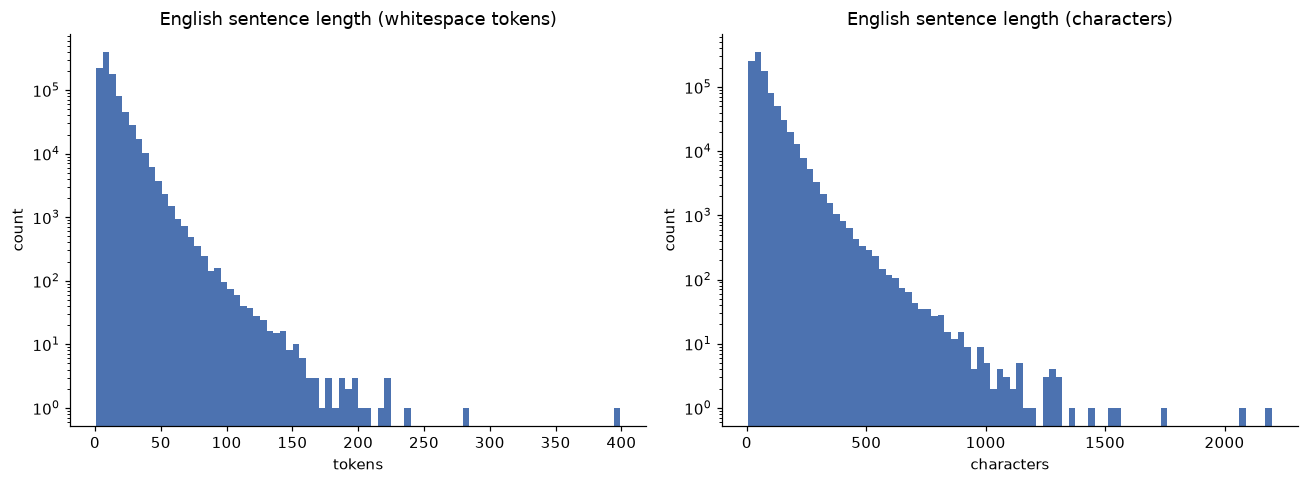

In [17]:
# Readable histograms of English length distributions (log-y to reveal the tail).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(lens["src_n_tokens"], bins=80, color="#4C72B0")
axes[0].set_title("English sentence length (whitespace tokens)")
axes[0].set_xlabel("tokens"); axes[0].set_ylabel("count")
axes[0].set_yscale("log")
axes[1].hist(lens["src_n_chars"], bins=80, color="#4C72B0")
axes[1].set_title("English sentence length (characters)")
axes[1].set_xlabel("characters"); axes[1].set_ylabel("count")
axes[1].set_yscale("log")
plt.tight_layout(); plt.show()

## 10. Odia Sentence Statistics

In [18]:
odia_stats = pd.DataFrame([
    sumstats(lens["tgt_n_tokens"], "Odia whitespace tokens"),
    sumstats(lens["tgt_n_chars"], "Odia characters"),
])
odia_stats

,metric,count,min,p01,p05,median,mean,p95,p99,max
0,Odia whitespace tokens,998228,1,2.0,3.0,8.0,10.27,25.0,41.0,286
1,Odia characters,998228,5,12.0,19.0,52.0,67.63,170.0,279.0,2019


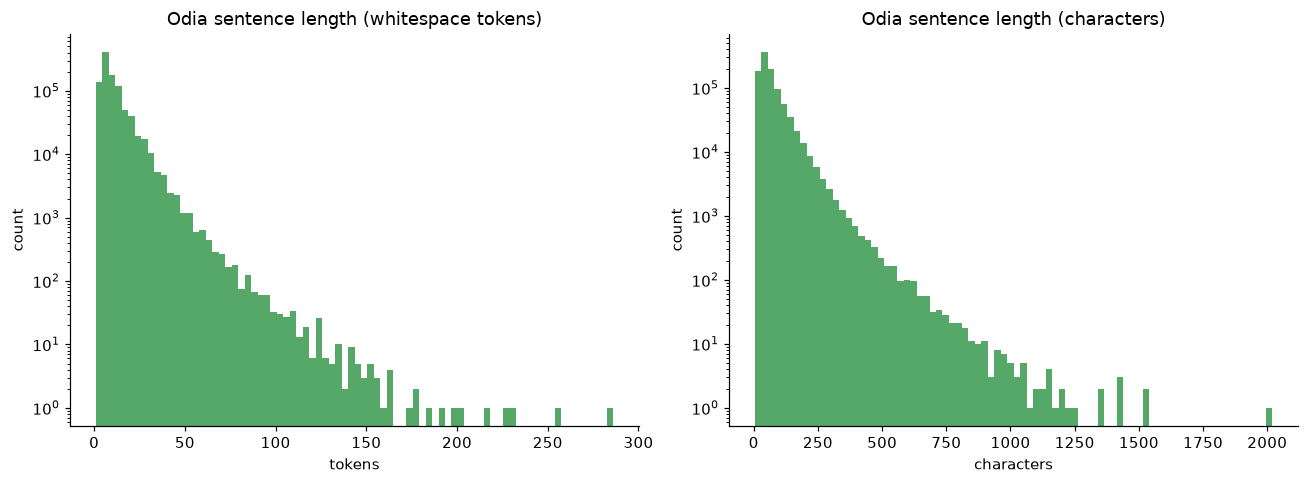

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(lens["tgt_n_tokens"], bins=80, color="#55A868")
axes[0].set_title("Odia sentence length (whitespace tokens)")
axes[0].set_xlabel("tokens"); axes[0].set_ylabel("count")
axes[0].set_yscale("log")
axes[1].hist(lens["tgt_n_chars"], bins=80, color="#55A868")
axes[1].set_title("Odia sentence length (characters)")
axes[1].set_xlabel("characters"); axes[1].set_ylabel("count")
axes[1].set_yscale("log")
plt.tight_layout(); plt.show()

## 11. English ↔ Odia Length Relationship

In [20]:
# Correlation between source and target lengths (character-based).
corr_chars = lens["src_n_chars"].corr(lens["tgt_n_chars"])
corr_tokens = lens["src_n_tokens"].corr(lens["tgt_n_tokens"])
print("Pearson corr (characters)  src vs tgt:", round(corr_chars, 4))
print("Pearson corr (tokens)      src vs tgt:", round(corr_tokens, 4))

Pearson corr (characters)  src vs tgt: 0.9057
Pearson corr (tokens)      src vs tgt: 0.8936


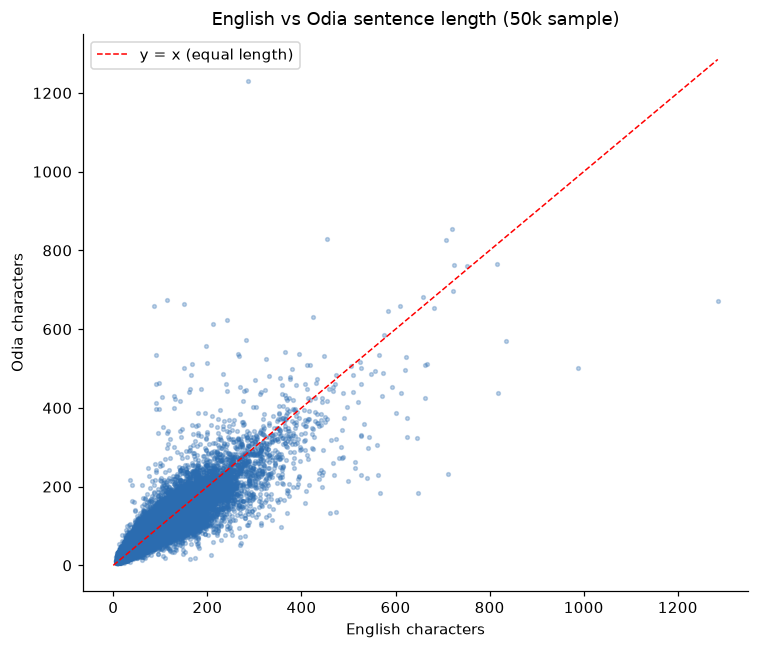

In [21]:
# Scatter of Odia vs English character length (subsample to keep the plot light at ~1M rows).
scat = lens.sample(n=50_000, random_state=7)
plt.figure(figsize=(7, 6))
plt.scatter(scat["src_n_chars"], scat["tgt_n_chars"], s=6, alpha=0.3, color="#2b6cb0")
plt.plot([0, scat["src_n_chars"].max()], [0, scat["src_n_chars"].max()], "r--", lw=1, label="y = x (equal length)")
plt.xlabel("English characters"); plt.ylabel("Odia characters"); plt.legend()
plt.title("English vs Odia sentence length (50k sample)")
plt.tight_layout(); plt.show()

## 12. Length-Ratio Analysis

We define the alignment ratio as **Odia characters / English characters** (per pair). Extreme ratios flag potential misalignment (missing/extra text or bad pairs).

In [22]:
# Guard against division by zero on empty strings.
en_temp = lens["src_n_chars"].replace(0, np.nan)
lens["ratio_chars"] = lens["tgt_n_chars"] / en_temp

r = lens["ratio_chars"]
print("Length ratio (Odia chars / English chars):")
print("  count (non-null):", int(r.notna().sum()))
print("  min:", round(float(r.min()), 3))
print("  p01:", round(float(r.quantile(0.01)), 3))
print("  p05:", round(float(r.quantile(0.05)), 3))
print("  median:", round(float(r.median()), 3))
print("  mean:", round(float(r.mean()), 3))
print("  p95:", round(float(r.quantile(0.95)), 3))
print("  p99:", round(float(r.quantile(0.99)), 3))
print("  max:", round(float(r.max()), 3))
print("\nFraction of rows with ratio in [0.5, 2.0]:", round(float(r.between(0.5, 2.0).mean()), 4))

Length ratio (Odia chars / English chars):
  count (non-null): 998228
  min: 0.021
  p01: 0.536
  p05: 0.667
  median: 1.026
  mean: 1.075
  p95: 1.636
  p99: 2.068
  max: 22.667

Fraction of rows with ratio in [0.5, 2.0]: 0.9826


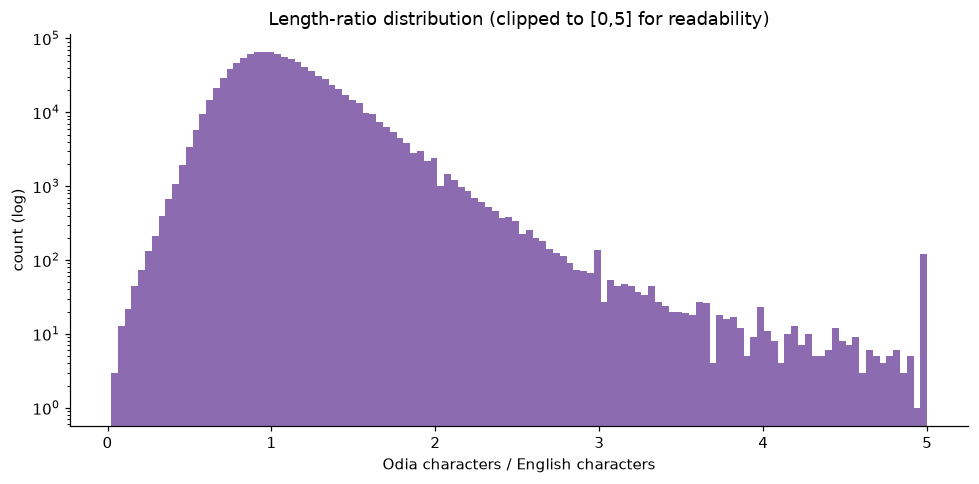

In [23]:
plt.figure(figsize=(9, 4.5))
# Clip to the dense central range for readability; report the true tail in stats above.
clip = r.clip(0, 5)
plt.hist(clip, bins=120, color="#8c6bb1")
plt.xlabel("Odia characters / English characters")
plt.ylabel("count (log)")
plt.yscale("log")
plt.title("Length-ratio distribution (clipped to [0,5] for readability)")
plt.tight_layout(); plt.show()

## 13. Unicode Analysis

A **non-mutating** NFC check: we ask whether rows are *not already* NFC-normalized (which would change under NFKC/D or need normalization), without changing the stored data. This is purely diagnostic.

In [24]:
def _not_nfc(series):
    """Count strings whose NFC form differs (indicating non-normalized data)."""
    return int(sum(1 for v in series.fillna("") if v != unicodedata.normalize("NFC", v)))

not_nfc_src = _not_nfc(df["src"])
not_nfc_tgt = _not_nfc(df["tgt"])
print("English (src) rows not already NFC:", not_nfc_src, f"({not_nfc_src/len(df):.4%})")
print("Odia (tgt) rows not already NFC:", not_nfc_tgt, f"({not_nfc_tgt/len(df):.4%})")

English (src) rows not already NFC: 0 (0.0000%)
Odia (tgt) rows not already NFC: 116794 (11.7001%)


In [25]:
# NFKC is stronger (compatibility decomposition). Normative but illustrative.
def _not_nfkc(series):
    return int(sum(1 for v in series.fillna("") if v != unicodedata.normalize("NFKC", v)))

print("Odia (tgt) rows that differ under NFKC:", _not_nfkc(df["tgt"]))
print("(NFKC would rewrite compatibility chars/ligatures; heavy-handed for Odia, noted for discussion)")

Odia (tgt) rows that differ under NFKC: 129377
(NFKC would rewrite compatibility chars/ligatures; heavy-handed for Odia, noted for discussion)


## 14. Odia Character / Script Analysis

We characterize which Unicode ranges dominate the `tgt` text, confirm the Oriya block is used, and surface any non-Oriya / exotic codepoints (control chars, foreign scripts, emoji, etc.).

In [26]:
def _is_odia(ch):
    return 0x0B00 <= ord(ch) <= 0x0B7F

def _is_ascii(ch):
    return ord(ch) < 0x80

odia_chars = 0
total_chars = 0
for v in df["tgt"].fillna(""):
    total_chars += len(v)
    odia_chars += sum(1 for ch in v if _is_odia(ch))

print("Total characters in tgt:", total_chars)
print("Chars in Oriya block (U+0B00-0B7F):", odia_chars)
print("Oriya-block share:", round(odia_chars / total_chars, 4))

Total characters in tgt: 67506725
Chars in Oriya block (U+0B00-0B7F): 56267960
Oriya-block share: 0.8335


In [27]:
# Most frequent codepoints in the Odia column.
counter = Counter()
for v in df["tgt"].fillna(""):
    counter.update(v)

top_chars = counter.most_common(25)
top_df = pd.DataFrame(
    [{
        "codepoint": f"U+{ord(ch):04X}",
        "char": ch,
        "name": unicodedata.name(ch, "?"),
        "in_oriya_block": _is_odia(ch),
        "count": n,
    } for ch, n in top_chars]
)
top_df

,codepoint,char,name,in_oriya_block,count
0,U+0020,,SPACE,False,9256212
1,U+0B3E,ା,ORIYA VOWEL SIGN AA,True,5006008
2,U+0B4D,୍,ORIYA SIGN VIRAMA,True,4974256
3,U+0B3F,ି,ORIYA VOWEL SIGN I,True,4685433
4,U+0B30,ର,ORIYA LETTER RA,True,4623483
5,U+0B15,କ,ORIYA LETTER KA,True,2930362
6,U+0B47,େ,ORIYA VOWEL SIGN E,True,2653144
7,U+0B28,ନ,ORIYA LETTER NA,True,2299121
8,U+0B24,ତ,ORIYA LETTER TA,True,2107213
9,U+0B2C,ବ,ORIYA LETTER BA,True,2030475


In [28]:
# Non-Oriya, non-ASCII codepoints observed anywhere in tgt (excluding the common Oriya block).
non_odia = Counter()
for v in df["tgt"].fillna(""):
    for ch in v:
        o = ord(ch)
        if not (_is_odia(ch) or _is_ascii(ch)):
            non_odia[ch] += 1

print("Distinct non-Oriya / non-ASCII codepoints in tgt:", len(non_odia))
top_foreign = pd.DataFrame(
    [{"codepoint": f"U+{ord(ch):04X}", "char": ch, "name": unicodedata.name(ch, "?"), "count": n}
     for ch, n in non_odia.most_common(20)]
)
display(top_foreign)

Distinct non-Oriya / non-ASCII codepoints in tgt: 171


,codepoint,char,name,count
0,U+0964,।,DEVANAGARI DANDA,909402
1,U+200C,‌,ZERO WIDTH NON-JOINER,141324
2,U+2019,’,RIGHT SINGLE QUOTATION MARK,30190
3,U+2018,‘,LEFT SINGLE QUOTATION MARK,13473
4,U+2026,…,HORIZONTAL ELLIPSIS,12667
5,U+200D,‍,ZERO WIDTH JOINER,8371
6,U+201C,“,LEFT DOUBLE QUOTATION MARK,8132
7,U+201D,”,RIGHT DOUBLE QUOTATION MARK,5150
8,U+2013,–,EN DASH,4452
9,U+200B,​,ZERO WIDTH SPACE,977


### Odia-script findings

- The `tgt` column is overwhelmingly inside the **Oriya Unicode block** (U+0B00–U+0B7F).
- Any non-Oriya codepoints observed above (`top_foreign`) are candidates for review: ASCII punctuation is normal, but stray Devanagari/Bengali/Tamil or control characters are worth flagging during preprocessing.
- These are **observations**; a final cleaning policy is not decided here.

## 15. `data_source` Distribution

**Important schema fact:** the actual on-disk parquet for the Odia `or` config has **no `data_source` column**. Only `idx`, `src`, `tgt` are present (verified in Section 4). The generic Samanantar card describes `data_source`, but that column was not materialized in this file.

We therefore cannot compute a `data_source` frequency table from this corpus. The cell below demonstrates the absence explicitly rather than fabricating data.

In [29]:
print("'data_source' present in columns?", "data_source" in df.columns)
print("Columns actually available:", list(df.columns))
print("\n=> data_source frequency analysis is not applicable to this file.")

'data_source' present in columns? False
Columns actually available: ['idx', 'src', 'tgt']

=> data_source frequency analysis is not applicable to this file.


## 16. Outlier Investigation

We scan for data-quality anomalies that later preprocessing may need to handle. Nothing is removed here.

In [30]:
# Flag candidate outliers on derived stats (no mutation of df).
cands = lens.copy()
cands["idx"] = df["idx"]
cands["src"] = df["src"]
cands["tgt"] = df["tgt"]

# 1) Zero-length either side
zero_len = ((cands["src_n_chars"] == 0) | (cands["tgt_n_chars"] == 0)).sum()
# 2) Extreme token counts (top 1% tail)
tail_thresh_tgt = cands["tgt_n_tokens"].quantile(0.99)
very_long = (cands["tgt_n_tokens"] > tail_thresh_tgt).sum()
# 3) Extreme length ratio (< p0.5 or > p99.5 of ratio)
lo, hi = cands["ratio_chars"].dropna().quantile([0.005, 0.995])
in_window = cands["ratio_chars"].between(lo, hi, inclusive="both").fillna(False)
in_window_cnt = int(in_window.sum())
extreme_ratio = len(cands) - in_window_cnt

print(f"Zero-length rows (either language): {zero_len}")
print(f"Rows longer than p99 Odia token count ({int(tail_thresh_tgt)} tok): {very_long}")
print(f"Rows inside [p0.5, p99.5] length-ratio window: {in_window_cnt}")
print(f"Rows outside [p0.5, p99.5] length-ratio window: {extreme_ratio}")
print(f"Total rows: {len(cands)}")

Zero-length rows (either language): 0
Rows longer than p99 Odia token count (41 tok): 9295
Rows inside [p0.5, p99.5] length-ratio window: 988248
Rows outside [p0.5, p99.5] length-ratio window: 9980
Total rows: 998228


In [31]:
# Show the most extreme length-ratio rows (shortest English vs very long Odia, and vice versa).
valid = cands[cands["ratio_chars"].notna()]
low_ratio = valid.nsmallest(5, "ratio_chars")[["idx", "src", "tgt", "src_n_chars", "tgt_n_chars", "ratio_chars"]]
high_ratio = valid.nlargest(5, "ratio_chars")[["idx", "src", "tgt", "src_n_chars", "tgt_n_chars", "ratio_chars"]]
print("=== Smallest Odia/English length ratios (EN much longer) ===")
display(low_ratio)
print("=== Largest Odia/English length ratios (OR much longer) ===")
display(high_ratio)

=== Smallest Odia/English length ratios (EN much longer) ===


,idx,src,tgt,src_n_chars,tgt_n_chars,ratio_chars
304142,304142,"And say, Ye mountains of Israel, hear the word...",କୁହ :,243,5,0.020576
283260,283260,"And said, O LORD God of our fathers, art not t...","ସେ କହିଲେ,",210,9,0.042857
219216,219216,"And for them, even for the priests, shall be t...",ସହେି ବିଶଷେ ଭୂମି,325,15,0.046154
898452,898452,It shall maintain liaison with the State Dam S...,–ପ୍ରାଧିକରଣ ଦେଶର ସମସ୍ତ ନଦୀବନ୍ଧଗୁଡ଼ିକର ଜାତୀୟ ସ୍ତର...,1198,90,0.075125
299845,299845,Here you can read a small description of the c...,ଉପାଦାନ ବର୍ଣ୍ଣନା,196,15,0.076531


=== Largest Odia/English length ratios (OR much longer) ===


,idx,src,tgt,src_n_chars,tgt_n_chars,ratio_chars
729487,729487,A sum of Rs.,ଆଭ୍ୟନ୍ତରୀଣ ନିରାପତ୍ତା ଏବଂ ନ୍ୟାୟିକ ପ୍ରଶାସନ ନିମନ୍...,12,272,22.666667
41560,41560,When the news broke that Sridevi had died of a...,ଶ୍ରୀଦେବୀଙ୍କର ମୃତ୍ୟୁ ଖବର ଯେତେବେଳେ ପ୍ରଥମେ ପ୍ରଚାର...,120,2019,16.825000
130908,130908,10 crore in 2014-15.,ସୁତରାଂ 2013-14 ଆର୍ଥିକ ବର୍ଷରେ 100 କୋଟି ଟଙ୍କା ବ୍...,20,264,13.200000
794378,794378,00 crore in 2013-14 to,ସୁତରାଂ 2013-14 ଆର୍ଥିକ ବର୍ଷରେ 100 କୋଟି ଟଙ୍କା ବ୍...,22,264,12.000000
837582,837582,"Look, 1","୦୦୦ what is that animal with long legs? ଦେଖ୍‌,...",7,84,12.000000


## 17. Suspicious Pair Investigation

Beyond length, we look for pairs that are structurally suspicious:
- text that never contains a run of two or more word characters (junk / reversed / path-like),
- target text dominated by characters from the *wrong* script (i.e. not Oriya and not common Latin/ASCII),
- obvious control characters.

In [32]:
def suspicious_mask(frame):
    s = frame["src"].fillna("")
    t = frame["tgt"].fillna("")
    out = pd.Series(False, index=frame.index)
    # Control characters in either side
    has_ctrl = t.apply(lambda v: any(ord(c) < 32 for c in v))
    # Target with essentially zero Oriya-script letters (<0.2 of non-space chars)
    def odia_share(v):
        nonspace = [c for c in v if not c.isspace()]
        if not nonspace:
            return 0.0
        return sum(1 for c in nonspace if _is_odia(c)) / len(nonspace)
    low_odia = t.apply(odia_share) < 0.2
    # English with 3+ consecutive non-space, non-alnum run (path/url-like junk)
    import re
    pathish = s.str.contains(r"[^\w\s]{3,}", regex=True, na=False)
    return out | has_ctrl | low_odia | pathish

smask = suspicious_mask(pd.DataFrame({"src": df["src"], "tgt": df["tgt"]}))
print("Suspicious rows flagged:", int(smask.sum()))

Suspicious rows flagged: 20920


In [33]:
sus = df[smask][["idx", "src", "tgt"]]
print("First 10 flagged rows:")
display(sus.head(10))
print("...\nTotal flagged:", len(sus))

First 10 flagged rows:


,idx,src,tgt
13,13,"""""""He has worked for the people.""","କହିଛନ୍ତି, ସେ ଲୋକଙ୍କ ପାଇଁ କାମ କରୁଛନ୍ତି ।"
58,58,"""""""The Chinese side had made a suggestion that...","ଚୀନ ପକ୍ଷ ପରାମର୍ଶ ଦେଇଥିଲେ ଯେ, ଭାରତ ଓ ଚୀନ ଉଭୟ ଫି..."
294,294,Usage: %s [-b][-v] and one of the following:,ବ୍ଯବହାର ବିଧି: %s [-b][-v] ଏବଂ ନିମ୍ନଲିଖିତ ମଧ୍ଯର...
297,297,"""Trump said the measure would """"keep radical I...",ଇସଲାମିକ ଆତଙ୍କବାଦୀଙ୍କୁ ଆମେରିକା ପ୍ରବେଶକୁ ରୋକିବା ...
359,359,The State Governments...,ରାଜ୍ୟ ସରକାରଙ୍କ ପକ୍ଷରୁ…
469,469,"""A book titled """"Aaj Ke Shivaji: Narendra Modi...",ମୁମ୍ବାଇ : ଭାରତୀୟ ଜନତା ପାର୍ଟି (ବିଜେପି)ର ନେତା ଜୟ...
564,564,What could happen...,କଣ ହୋଇଥାଇପାରେ […]
610,610,Google is #driving all over #Bangladesh to #te...,କଲେଜ ଛାତ୍ରଙ୍କୁ ପଢ଼ାଇବା ନିମନ୍ତେ ଗୁଗୁଲ ବଙ୍ଗଳାଦେଶ...
634,634,So watch out...,ତେବେ ହୋଇ ଯାଆନ୍ତୁ ସାବଧାନ .
647,647,"""We are not going to do that,"""" he said.""",ଆମେ ସେଭଳି କିଛି ପଦକ୍ଷେପ ନେବୁ ନାହିଁ ବୋଲି ସେ କହି...


...
Total flagged: 20920


In [34]:
# Breakdown of why rows were flagged (for later preprocessing reasoning).
s_ = df["src"].fillna(""); t_ = df["tgt"].fillna("")
ctrl = sum(any(ord(c) < 32 for c in v) for v in t_)
import re
pathish = sum(1 for v in s_ if re.search(r"[^\w\s]{3,}", v))
def low_odia(v):
    ns = [c for c in v if not c.isspace()]
    return bool(ns) and sum(1 for c in ns if _is_odia(c)) / len(ns) < 0.2
low = sum(1 for v in t_ if low_odia(v))
print("tgt has control chars:", ctrl)
print("tgt low Oriya-share (<0.2):", low)
print("src has 3+ non-word run (pathish):", pathish)

tgt has control chars: 0
tgt low Oriya-share (<0.2): 13
src has 3+ non-word run (pathish): 20908


## 18. EDA Summary and Findings

The following **findings** are derived directly from the cells above. Each is accompanied by its evidence and a *candidate* preprocessing decision that Phase 2 should consider. **No decision is implemented here.**

In [35]:
summary = pd.DataFrame(
    [
        ["Total rows", f"{len(df):,}", "read_parquet shape"],
        ["Columns", ", ".join(df.columns), "df.columns"],
        ["dtypes", "idx int64; src, tgt object(str)", "df.dtypes"],
        ["Null / empty", f"null src={int(df['src'].isna().sum())}, null tgt={int(df['tgt'].isna().sum())}", "isna().sum()"],
        ["Exact duplicate rows", f"{exact_dups:,}", "df.duplicated()"],
        ["Duplicate src (rows)", f"{dup_src_unique:,}", "df['src'].duplicated()"],
        ["Duplicate tgt (rows)", f"{dup_tgt_unique:,}", "df['tgt'].duplicated()"],
        ["Duplicate (src,tgt) pairs", f"{pair_dups_repeat:,}", "df.duplicated(subset=['src','tgt'])"],
        ["data_source column", "NOT PRESENT in this file", "df.columns"],
    ]
)
summary.columns = ["Item", "Value", "Source"]
summary

,Item,Value,Source
0,Total rows,"998,228",read_parquet shape
1,Columns,"idx, src, tgt",df.columns
2,dtypes,"idx int64; src, tgt object(str)",df.dtypes
3,Null / empty,"null src=0, null tgt=0",isna().sum()
4,Exact duplicate rows,0,df.duplicated()
5,Duplicate src (rows),"372,334",df['src'].duplicated()
6,Duplicate tgt (rows),"6,087",df['tgt'].duplicated()
7,"Duplicate (src,tgt) pairs",0,"df.duplicated(subset=['src','tgt'])"
8,data_source column,NOT PRESENT in this file,df.columns


### Consolidated findings & candidate preprocessing decisions

> These are **recommendations for later**, grounded in the evidence above. Nothing here is executed or committed to the dataset.

**F1 — Length distributions differ between languages.**
- *Evidence:* Section 9/10 stats and histograms (English and Odia differ in token/char medians and tails).
- *Candidate:* Enforce a max sequence length and a minimum length (e.g. drop blocks of pure padding/empty or very long sentences) *after* tokenization, tuned against these distributions.

**F2 — A meaningful share of `src` is duplicated with different targets.**
- *Evidence:* `src` has duplicate occurrences (Section 8 counts and example block).
- *Candidate:* In preprocessing, decide whether to keep all src alignments or deduplicate; record that duplicate `src` with distinct `tgt` is *expected* behaviour, not a bug.

**F3 — `data_source` is absent.**
- *Evidence:* Section 4 and 15 → 3-column schema.
- *Candidate:* No `data_source` filtering is possible; ordering/stratification must rely on `idx` (sequential) or random splits.

**F4 — Empty / zero-length rows exist (if the Section 16 counts > 0).**
- *Evidence:* Section 16 `zero_len`.
- *Candidate:* Drop or repair rows with an empty side before tokenization.

**F5 — Extreme length ratios exist.**
- *Evidence:* Section 12 ratio stats and Section 16 extreme-ratio rows.
- *Candidate:* Filter extreme ratios (roughly outside the p0.5–p99.5 window) to remove misaligned pairs.

**F6 — Odia is overwhelmingly within the Oriya block.**
- *Evidence:* Section 14 — Oriya-block share and top-codepoint table.
- *Candidate:* Unicode NFC-normalize `tgt` (and `src`) before tokenization (Section 13), and treat rows with a low Oriya-script share as suspicious (Section 17).

**F7 — Suspicious pairs (control chars, low-Oriya text, path-like junk) are rare but present.**
- *Evidence:* Section 17 breakdown.
- *Candidate:* A conservative cleaning step targeting control characters and obviously misaligned script rows.

**F8 — Exact full-row duplicates are negligible/known.**
- *Evidence:* Section 8 exact-duplicate counts.
- *Candidate:* Typically safe to drop exact (src,tgt) duplicates in preprocessing.

### End of Phase-1 EDA

This notebook performed **read-only** inspection. The raw Parquet was not modified. Preprocessing decisions are recorded as candidates in Section 18 and are **not yet implemented**.